In [1]:

# # Step 2: Install Kaggle API
# !pip install kaggle -q

# # Step 3: Setup your Kaggle API key
# import os
# os.makedirs('/root/.kaggle', exist_ok=True)

# # Note: Keep your API key private!
# kaggle_json = '{"username":"dinithrusiru1","key":"KGAT_f35f48309bc6e1677ac1162ecfd03afc"}'

# with open('/root/.kaggle/kaggle.json', 'w') as f:
#     f.write(kaggle_json)

# os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name:
    print('Found GPU at: {}'.format(device_name))
else:
    raise SystemError('GPU device not found')


Found GPU at: /device:GPU:0


In [4]:
!nvidia-smi

Thu Mar  5 13:29:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             33W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# # Step 4: Create a folder in your Google Drive for the dataset
# # This creates a folder named 'KaggleData' in your Drive
# drive_path2 = '/content/drive/MyDrive/da/children-emotions'
# os.makedirs(drive_path2, exist_ok=True)

# # Step 5: Download directly to Drive
# # We point the -p (path) to your Google Drive folder
# !kaggle datasets download -d fatmamtalaat/autistic-children-emotions-dr-fatma-m-talaat -p {drive_path2} --unzip

# print(f'Done! Your dataset is now permanently in: {drive_path2}')

In [6]:
# # Step 4: Create a folder in your Google Drive for the dataset
# # This creates a folder named 'KaggleData' in your Drive
# drive_path = '/content/drive/MyDrive/da/affectnet'
# os.makedirs(drive_path, exist_ok=True)

# # Step 5: Download directly to Drive
# # We point the -p (path) to your Google Drive folder
# !kaggle datasets download -d mstjebashazida/affectnet -p {drive_path} --unzip

# print(f'Done! Your dataset is now permanently in: {drive_path}')

In [7]:
# # Step 4: Create a folder in your Google Drive for the dataset
# # This creates a folder named 'KaggleData' in your Drive
# drive_path2 = '/content/drive/MyDrive/da/children-emotions'
# os.makedirs(drive_path2, exist_ok=True)

# # Step 5: Download directly to Drive
# # We point the -p (path) to your Google Drive folder
# !kaggle datasets download -d nishchalchandel/raf-db-face-emotion-dataset -p {drive_path2} --unzip

# print(f'Done! Your dataset is now permanently in: {drive_path2}')

In [8]:
# ════════════════════════════════════════════════════════════
# 🧠 Child Anxiety Detection — 3-Stage Pipeline
# Stage 1+1B: AffectNet → Stage 2: RAF-DB → Stage 3: Children
# ════════════════════════════════════════════════════════════

# ── CELL 1 — Install & Import ─────────────────────────────────
!pip install tensorflow matplotlib scikit-learn seaborn -q

import os, math, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# ── CELL 2 — Mount Drive & Paths ──────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

# ── CHANGE THESE TO YOUR PATHS ────────────────────────────────
AFFECTNET_PATH = '/content/drive/MyDrive/da/affectnet/archive (3)'
RAFDB_PATH     = '/content/drive/MyDrive/da/children-emotions'
CHILDREN_PATH  = '/content/drive/MyDrive/da/children-emotions/Autism emotion recogition dataset/Autism emotion recogition dataset'
SAVE_PATH      = '/content/drive/MyDrive/da/model2'

os.makedirs(SAVE_PATH, exist_ok=True)

def get_split(base, split):
    for name in [split, split.lower(), split.capitalize()]:
        p = os.path.join(base, name)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'Cannot find {split} in {base}')

AFFECTNET_TRAIN = get_split(AFFECTNET_PATH, 'Train')
AFFECTNET_TEST  = get_split(AFFECTNET_PATH, 'Test')
RAFDB_TRAIN     = get_split(RAFDB_PATH,     'train')
RAFDB_TEST      = get_split(RAFDB_PATH,     'test')
CHILDREN_TRAIN  = get_split(CHILDREN_PATH,  'train')
CHILDREN_TEST   = get_split(CHILDREN_PATH,  'test')

print('✅ Paths ready:')
for label, path in [
    ('AffectNet Train', AFFECTNET_TRAIN),
    ('AffectNet Test',  AFFECTNET_TEST),
    ('RAF-DB Train',    RAFDB_TRAIN),
    ('RAF-DB Test',     RAFDB_TEST),
    ('Children Train',  CHILDREN_TRAIN),
    ('Children Test',   CHILDREN_TEST),
]:
    print(f'   {label:20s}: {sorted(os.listdir(path))}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths ready:
   AffectNet Train     : ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   AffectNet Test      : ['Anger', 'Contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   RAF-DB Train        : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   RAF-DB Test         : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   Children Train      : ['Natural', 'anger', 'fear', 'joy', 'sadness', 'surprise']
   Children Test       : ['Natural', 'anger', 'fear', 'joy', 'sadness', 'surprise']


In [10]:
# ── CELL 3 — Configuration ────────────────────────────────────

IMG_SIZE  = (128, 128)
IMG_SHAPE = (128, 128, 3)

# ── CLASS DEFINITIONS ─────────────────────────────────────────
AFFECTNET_CLASSES = ['anger', 'fear', 'happy', 'neutral', 'sad']
NUM_AFFECTNET     = 5

# RAF-DB — skip disgust and surprise, use only 5 matching emotions
RAFDB_CLASSES     = ['angry', 'fear', 'happy', 'neutral', 'sad']
NUM_RAFDB         = 5

# Children — 5 anxiety-relevant emotions
CHILDREN_CLASSES  = ['Natural', 'anger', 'fear', 'joy', 'sadness']
NUM_CHILDREN      = 5

# ── BATCH SIZES ───────────────────────────────────────────────
BATCH_AFFECTNET = 32
BATCH_RAFDB     = 32
BATCH_CHILDREN  = 16

# ── LEARNING RATES ────────────────────────────────────────────
LR_S1   = 1e-3    # Stage 1:  frozen base
LR_S1B  = 1e-5    # Stage 1B: unfreeze top 60
LR_S2   = 5e-6    # Stage 2:  RAF-DB finetune
LR_S3   = 3e-6    # Stage 3:  Children finetune

# ── EPOCHS ────────────────────────────────────────────────────
EPOCHS_S1   = 30
EPOCHS_S1B  = 20
EPOCHS_S2   = 20
EPOCHS_S3   = 50

# ── ANXIETY WEIGHTS ───────────────────────────────────────────
ANXIETY_WEIGHTS = {
    'fear'   : 1.0,
    'sadness': 0.75,
    'anger'  : 0.6,
    'Natural': 0.0,
    'joy'    : 0.0,
}

print('✅ Config ready')
print(f'   IMG_SIZE         : {IMG_SIZE}')
print(f'   AffectNet LR     : {LR_S1} → {LR_S1B}')
print(f'   RAF-DB LR        : {LR_S2}')
print(f'   Children LR      : {LR_S3}')

✅ Config ready
   IMG_SIZE         : (128, 128)
   AffectNet LR     : 0.001 → 1e-05
   RAF-DB LR        : 5e-06
   Children LR      : 3e-06


In [11]:
# ── CELL 4 — Dataset Distribution ────────────────────────────

def get_counts(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        p = os.path.join(folder, cls)
        if os.path.isdir(p):
            counts[cls] = len([
                f for f in os.listdir(p)
                if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))
            ])
    return counts

print('AffectNet Train:', get_counts(AFFECTNET_TRAIN))
print('RAF-DB Train   :', get_counts(RAFDB_TRAIN))
print('Children Train :', get_counts(CHILDREN_TRAIN))
print('Children Test  :', get_counts(CHILDREN_TEST))

AffectNet Train: {'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}
RAF-DB Train   : {'angry': 705, 'disgust': 717, 'fear': 281, 'happy': 4772, 'neutral': 2524, 'sad': 1982, 'surprise': 1290}
Children Train : {'Natural': 200, 'anger': 200, 'fear': 200, 'joy': 200, 'sadness': 199, 'surprise': 200}
Children Test  : {'Natural': 40, 'anger': 40, 'fear': 36, 'joy': 35, 'sadness': 38, 'surprise': 37}


In [12]:
# ── CELL 5 — Callbacks & Plot Helpers ────────────────────────

def make_callbacks(filename, patience_es=5, patience_lr=3, min_lr=1e-9):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=patience_es,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience_lr,
            min_lr=min_lr,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{SAVE_PATH}/{filename}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train', color='steelblue',  lw=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   color='darkorange', lw=2)
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylim([0, 1.05])
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.axhline(y=max(history.history['val_accuracy']),
                color='darkorange', linestyle='--', alpha=0.5)

    ax2.plot(history.history['loss'],     label='Train', color='steelblue',  lw=2)
    ax2.plot(history.history['val_loss'], label='Val',   color='darkorange', lw=2)
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    fname = title.replace(' ', '_').replace('/', '_')
    plt.savefig(f'{SAVE_PATH}/{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'   Best val accuracy: {max(history.history["val_accuracy"])*100:.2f}%')

print('✅ Helpers ready')

✅ Helpers ready


In [13]:
# ── CELL 6 — Build Model ──────────────────────────────────────

def build_model(num_classes, input_shape=IMG_SHAPE):
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dense(256, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(128, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.3)(x)

    output = Dense(num_classes, activation='softmax')(x)
    model  = Model(inputs=base.input, outputs=output)
    return model, base

model, base_model = build_model(NUM_AFFECTNET)
model.compile(
    optimizer=Adam(learning_rate=LR_S1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total     = len(model.layers)
trainable = sum(1 for l in model.layers if l.trainable)
print(f'✅ Model built — {total} layers, {trainable} trainable')

✅ Model built — 162 layers, 8 trainable


In [14]:
# ── CELL 7 — AffectNet Generators ────────────────────────────

affectnet_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.15
).flow_from_directory(
    AFFECTNET_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_AFFECTNET,
    class_mode='categorical',
    classes=AFFECTNET_CLASSES,
    subset='training',
    shuffle=True
)

affectnet_val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
).flow_from_directory(
    AFFECTNET_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_AFFECTNET,
    class_mode='categorical',
    classes=AFFECTNET_CLASSES,
    subset='validation',
    shuffle=False
)

print(f'✅ AffectNet generators ready')
print(f'   Classes : {affectnet_train_gen.class_indices}')
print(f'   Train   : {affectnet_train_gen.samples:,}')
print(f'   Val     : {affectnet_val_gen.samples:,}')

Found 9523 images belonging to 5 classes.
Found 1678 images belonging to 5 classes.
✅ AffectNet generators ready
   Classes : {'anger': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4}
   Train   : 9,523
   Val     : 1,678


🚀 STAGE 1 — AffectNet | Base FROZEN | LR = 0.001



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4026 - loss: 1.6711
Epoch 1: val_accuracy improved from -inf to 0.57332, saving model to /content/drive/MyDrive/da/model2/stage1.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 2067s 7s/step - accuracy: 0.4027 - loss: 1.6704 - val_accuracy: 0.5733 - val_loss: 1.0067 - learning_rate: 0.0010
Epoch 2/30
  1/297 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.3438 - loss: 1.4000

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.57332
297/297 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.3438 - loss: 1.4000 - val_accuracy: 0.5733 - val_loss: 1.0030 - learning_rate: 0.0010
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.4980 - loss: 1.2262
Epoch 3: val_accuracy improved from 0.57332 to 0.60397, saving model to /content/drive/MyDrive/da/model2/stage1.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 83s 278ms/step - accuracy: 0.4981 - loss: 1.2261 - val_accuracy: 0.6040 - val_loss: 0.9601 - learning_rate: 0.0010
Epoch 4/30
  1/297 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.4375 - loss: 1.3133
Epoch 4: val_accuracy did not improve from 0.60397
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4375 - loss: 1.3133 - val_accuracy: 0.5986 - val_loss: 0.9619 - learning_rate: 0.0010
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.5278 - loss: 1.1278
Epoch 5: val_accuracy improved from 0.60397 to 0.61478, saving model to /content/drive/

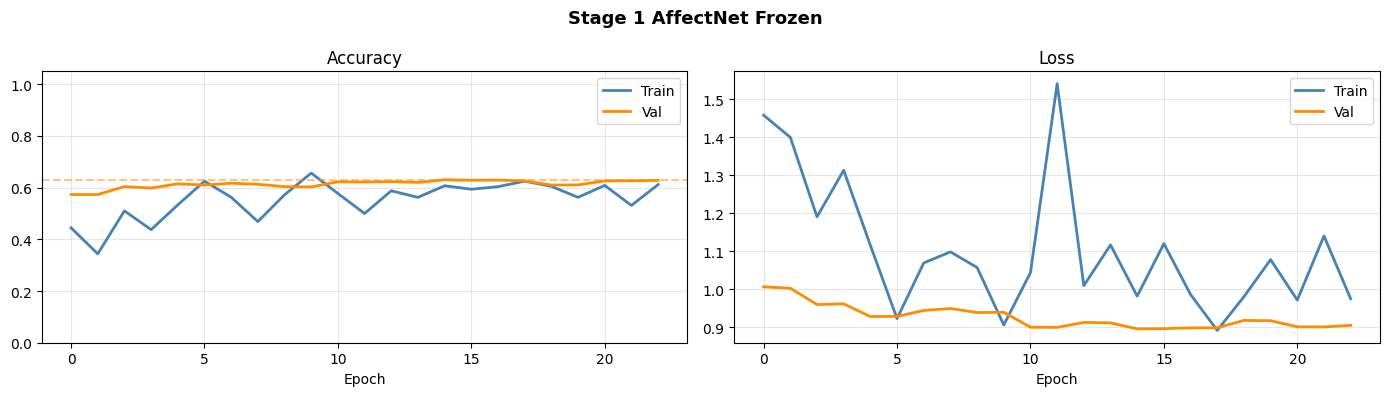

   Best val accuracy: 63.04%
✅ Stage 1 good — continue to Stage 1B


In [15]:
# ── CELL 8 — STAGE 1: AffectNet Frozen ───────────────────────

print(f'🚀 STAGE 1 — AffectNet | Base FROZEN | LR = {LR_S1}\n')

history_s1 = model.fit(
    affectnet_train_gen,
    validation_data=affectnet_val_gen,
    epochs=EPOCHS_S1,
    steps_per_epoch=math.floor(affectnet_train_gen.samples / BATCH_AFFECTNET),
    validation_steps=math.floor(affectnet_val_gen.samples  / BATCH_AFFECTNET),
    callbacks=make_callbacks('stage1', patience_es=8, patience_lr=4),
    verbose=1
)

plot_history(history_s1, 'Stage 1 AffectNet Frozen')

best_s1 = max(history_s1.history['val_accuracy'])
if best_s1 < 0.50:
    print('⚠️  WARNING: below 50% — check data paths before continuing')
else:
    print('✅ Stage 1 good — continue to Stage 1B')

🔓 STAGE 1B — Top 60 UNFROZEN | LR = 1e-05
   Trainable layers: 45

Epoch 1/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.6201 - loss: 0.9388
Epoch 1: val_accuracy improved from -inf to 0.64603, saving model to /content/drive/MyDrive/da/model2/stage1b.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 112s 322ms/step - accuracy: 0.6201 - loss: 0.9388 - val_accuracy: 0.6460 - val_loss: 0.8476 - learning_rate: 1.0000e-05
Epoch 2/20
  1/297 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5000 - loss: 1.2311
Epoch 2: val_accuracy did not improve from 0.64603
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5000 - loss: 1.2311 - val_accuracy: 0.6364 - val_loss: 0.8722 - learning_rate: 1.0000e-05
Epoch 3/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.6511 - loss: 0.8956
Epoch 3: val_accuracy did not improve from 0.64603
297/297 ━━━━━━━━━━━━━━━━━━━━ 84s 283ms/step - accuracy: 0.6511 - loss: 0.8955 - val_accuracy: 0.6430 - val_loss: 0.8284 - learning_rate: 1.0000e-05
Epoch 4/2

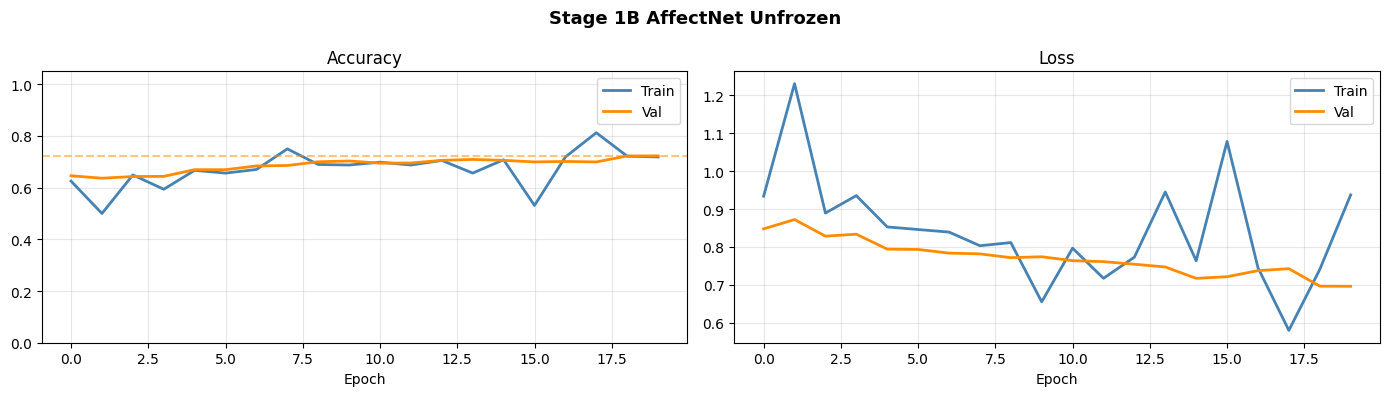

   Best val accuracy: 72.30%
✅ Stage 1B good — continue to Stage 2 RAF-DB


In [16]:
# ── CELL 9 — STAGE 1B: AffectNet Unfrozen ────────────────────

base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LR_S1B),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(1 for l in model.layers if l.trainable)
print(f'🔓 STAGE 1B — Top 60 UNFROZEN | LR = {LR_S1B}')
print(f'   Trainable layers: {trainable}\n')

history_s1b = model.fit(
    affectnet_train_gen,
    validation_data=affectnet_val_gen,
    epochs=EPOCHS_S1B,
    steps_per_epoch=math.floor(affectnet_train_gen.samples / BATCH_AFFECTNET),
    validation_steps=math.floor(affectnet_val_gen.samples  / BATCH_AFFECTNET),
    callbacks=make_callbacks('stage1bnew', patience_es=7, patience_lr=4),
    verbose=1
)

plot_history(history_s1b, 'Stage 1B AffectNet Unfrozen')

best_s1b = max(history_s1b.history['val_accuracy'])
if best_s1b < 0.55:
    print('⚠️  WARNING: still below 55% — consider retraining Stage 1')
else:
    print('✅ Stage 1B good — continue to Stage 2 RAF-DB')

🔓 STAGE 1B — Top 60 UNFROZEN | LR = 1e-05
   Trainable layers: 40

Epoch 1/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.7176 - loss: 0.7961
Epoch 1: val_accuracy improved from -inf to 0.71454, saving model to /content/drive/MyDrive/da/model2/stage1bnew.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 121s 349ms/step - accuracy: 0.7176 - loss: 0.7959 - val_accuracy: 0.7145 - val_loss: 0.7167 - learning_rate: 1.0000e-05
Epoch 2/20
  1/297 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7500 - loss: 0.6445
Epoch 2: val_accuracy improved from 0.71454 to 0.71635, saving model to /content/drive/MyDrive/da/model2/stage1bnew.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7500 - loss: 0.6445 - val_accuracy: 0.7163 - val_loss: 0.7153 - learning_rate: 1.0000e-05
Epoch 3/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.7296 - loss: 0.7123
Epoch 3: val_accuracy improved from 0.71635 to 0.73137, saving model to /content/drive/MyDrive/da/model2/stage1bnew.keras
297/297 ━━━━

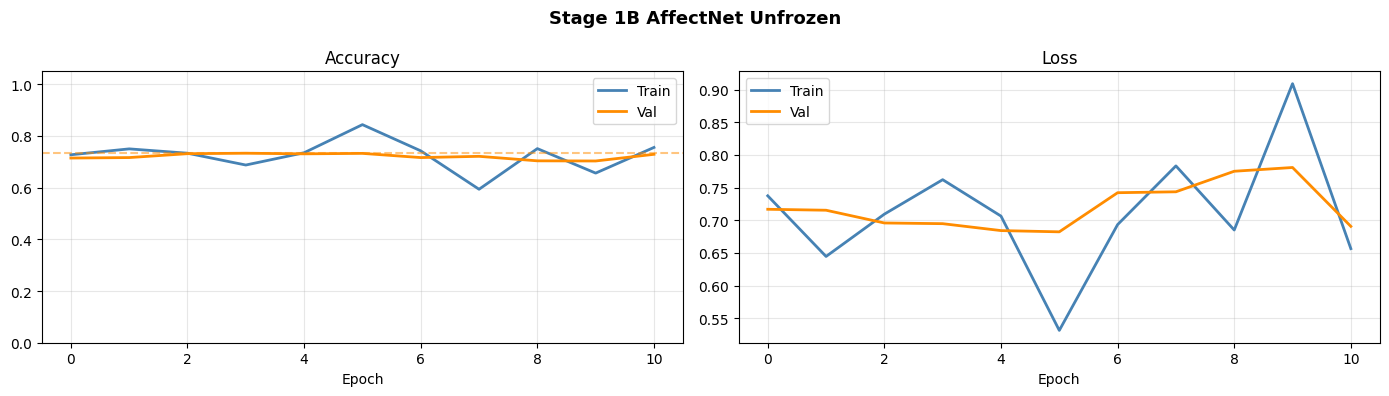

   Best val accuracy: 73.32%
✅ Stage 1B good — continue to Stage 2 RAF-DB


In [20]:
# ── CELL 9 — STAGE 1B: AffectNet Unfrozen ────────────────────

base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LR_S1B),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(1 for l in model.layers if l.trainable)
print(f'🔓 STAGE 1B — Top 60 UNFROZEN | LR = {LR_S1B}')
print(f'   Trainable layers: {trainable}\n')

history_s1b = model.fit(
    affectnet_train_gen,
    validation_data=affectnet_val_gen,
    epochs=EPOCHS_S1B,
    steps_per_epoch=math.floor(affectnet_train_gen.samples / BATCH_AFFECTNET),
    validation_steps=math.floor(affectnet_val_gen.samples  / BATCH_AFFECTNET),
    callbacks=make_callbacks('stage1bnew', patience_es=7, patience_lr=4),
    verbose=1
)

plot_history(history_s1b, 'Stage 1B AffectNet Unfrozen')

best_s1b = max(history_s1b.history['val_accuracy'])
if best_s1b < 0.55:
    print('⚠️  WARNING: still below 55% — consider retraining Stage 1')
else:
    print('✅ Stage 1B good — continue to Stage 2 RAF-DB')

In [21]:
# ── CELL 10 — Replace Head for RAF-DB ────────────────────────

model = load_model(f'{SAVE_PATH}/stage1bnew.keras')
print(f'Loaded stage1bnew ({len(model.layers)} layers)')

old_output_layer      = model.layers[-1]
old_weights, old_bias = old_output_layer.get_weights()
print(f'Old output shape: {old_weights.shape}')

# AffectNet → RAF-DB mapping (5 matching emotions only)
AFFECTNET_TO_RAFDB = {
    'anger'  : 'angry',
    'fear'   : 'fear',
    'happy'  : 'happy',
    'neutral': 'neutral',
    'sad'    : 'sad',
}

print('\nAffectNet → RAF-DB mapping:')
for a, r in AFFECTNET_TO_RAFDB.items():
    ai = AFFECTNET_CLASSES.index(a)
    ri = RAFDB_CLASSES.index(r)
    print(f'   [{ai}] {a:8s} → [{ri}] {r}')

# Find last dropout
last_dropout_idx = None
for i, layer in reversed(list(enumerate(model.layers))):
    if isinstance(layer, tf.keras.layers.Dropout):
        last_dropout_idx = i
        break

# Build RAF-DB head
x           = model.layers[last_dropout_idx].output
rafdb_out   = Dense(NUM_RAFDB, activation='softmax', name='rafdb_head')(x)
model_s2    = Model(inputs=model.input, outputs=rafdb_out)

# Transfer weights
new_weights = np.zeros((old_weights.shape[0], NUM_RAFDB))
new_bias    = np.zeros(NUM_RAFDB)

for a_name, r_name in AFFECTNET_TO_RAFDB.items():
    ai = AFFECTNET_CLASSES.index(a_name)
    ri = RAFDB_CLASSES.index(r_name)
    new_weights[:, ri] = old_weights[:, ai]
    new_bias[ri]       = old_bias[ai]

model_s2.get_layer('rafdb_head').set_weights([new_weights, new_bias])

# Freeze + compile
for layer in model_s2.layers[:-60]:
    layer.trainable = False
for layer in model_s2.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_s2.compile(
    optimizer=Adam(learning_rate=LR_S2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(1 for l in model_s2.layers if l.trainable)
print(f'\n✅ RAF-DB model ready')
print(f'   Classes          : {RAFDB_CLASSES}')
print(f'   Trainable layers : {trainable} / {len(model_s2.layers)}')

Loaded stage1bnew (162 layers)
Old output shape: (128, 5)

AffectNet → RAF-DB mapping:
   [0] anger    → [0] angry
   [1] fear     → [1] fear
   [2] happy    → [2] happy
   [3] neutral  → [3] neutral
   [4] sad      → [4] sad

✅ RAF-DB model ready
   Classes          : ['angry', 'fear', 'happy', 'neutral', 'sad']
   Trainable layers : 40 / 162


In [22]:
# ── CELL 11 — RAF-DB Generators ──────────────────────────────

rafdb_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    zoom_range=0.15,
    fill_mode='nearest',
    validation_split=0.15
).flow_from_directory(
    RAFDB_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_RAFDB,
    class_mode='categorical',
    classes=RAFDB_CLASSES,
    subset='training',
    shuffle=True
)

rafdb_val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
).flow_from_directory(
    RAFDB_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_RAFDB,
    class_mode='categorical',
    classes=RAFDB_CLASSES,
    subset='validation',
    shuffle=False
)

print(f'✅ RAF-DB generators ready')
print(f'   Classes : {rafdb_train_gen.class_indices}')
print(f'   Train   : {rafdb_train_gen.samples:,}')
print(f'   Val     : {rafdb_val_gen.samples:,}')

Found 8727 images belonging to 5 classes.
Found 1537 images belonging to 5 classes.
✅ RAF-DB generators ready
   Classes : {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4}
   Train   : 8,727
   Val     : 1,537


🚀 STAGE 2 — RAF-DB Finetune | LR = 5e-06

Epoch 1/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.4991 - loss: 1.5655 
Epoch 1: val_accuracy improved from -inf to 0.63151, saving model to /content/drive/MyDrive/da/model2/stage2_rafdb.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 5294s 19s/step - accuracy: 0.4993 - loss: 1.5646 - val_accuracy: 0.6315 - val_loss: 1.0218 - learning_rate: 5.0000e-06
Epoch 2/20
  1/272 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7500 - loss: 0.8977
Epoch 2: val_accuracy did not improve from 0.63151
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7500 - loss: 0.8977 - val_accuracy: 0.6315 - val_loss: 1.0212 - learning_rate: 5.0000e-06
Epoch 3/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6025 - loss: 1.1094
Epoch 3: val_accuracy improved from 0.63151 to 0.66927, saving model to /content/drive/MyDrive/da/model2/stage2_rafdb.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 75s 277ms/step - accuracy: 0.6025 - loss: 1.1093 - val_accuracy: 0.6693 - val

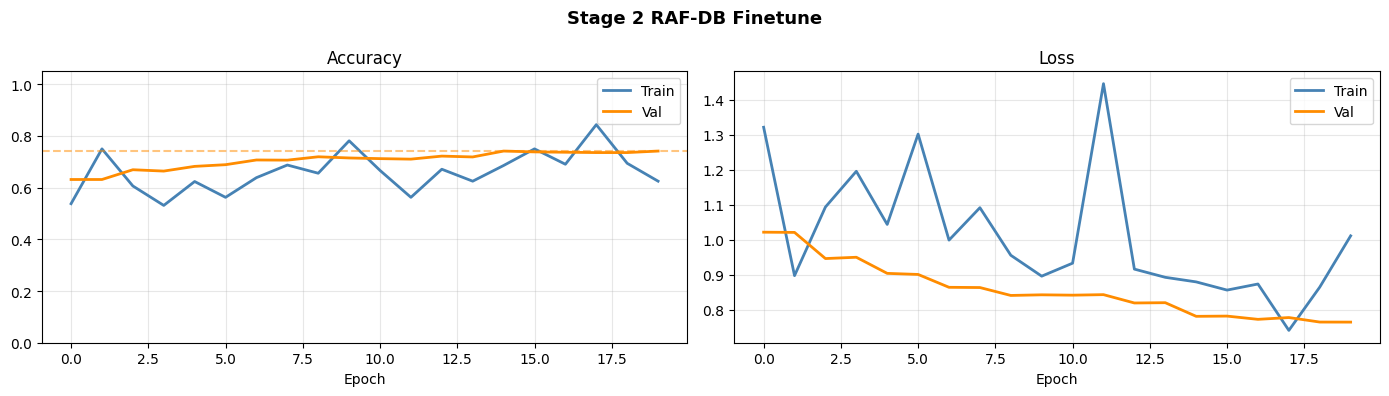

   Best val accuracy: 74.15%
✅ Stage 2 good — continue to Stage 3 Children


In [23]:
# ── CELL 12 — STAGE 2: RAF-DB Finetune ───────────────────────

print(f'🚀 STAGE 2 — RAF-DB Finetune | LR = {LR_S2}\n')

history_s2 = model_s2.fit(
    rafdb_train_gen,
    validation_data=rafdb_val_gen,
    epochs=EPOCHS_S2,
    steps_per_epoch=math.floor(rafdb_train_gen.samples / BATCH_RAFDB),
    validation_steps=math.floor(rafdb_val_gen.samples  / BATCH_RAFDB),
    callbacks=make_callbacks('stage2_rafdb', patience_es=7, patience_lr=4),
    verbose=1
)

plot_history(history_s2, 'Stage 2 RAF-DB Finetune')

best_s2 = max(history_s2.history['val_accuracy'])
if best_s2 < 0.60:
    print('⚠️  WARNING: RAF-DB below 60% — check class names match folders')
else:
    print('✅ Stage 2 good — continue to Stage 3 Children')

In [24]:
# ── CELL 13 — Replace Head for Children ──────────────────────

model_rafdb           = load_model(f'{SAVE_PATH}/stage2_rafdb.keras')
old_output_layer      = model_rafdb.layers[-1]
old_weights, old_bias = old_output_layer.get_weights()
print(f'Loaded stage2_rafdb ({len(model_rafdb.layers)} layers)')

# RAF-DB → Children mapping
RAFDB_TO_CHILDREN = {
    'angry'  : 'anger',
    'fear'   : 'fear',
    'happy'  : 'joy',
    'neutral': 'Natural',
    'sad'    : 'sadness',
}

print('\nRAF-DB → Children mapping:')
for r, c in RAFDB_TO_CHILDREN.items():
    ri = RAFDB_CLASSES.index(r)
    ci = CHILDREN_CLASSES.index(c)
    print(f'   [{ri}] {r:10s} → [{ci}] {c}')

# Find last dropout
last_dropout_idx = None
for i, layer in reversed(list(enumerate(model_rafdb.layers))):
    if isinstance(layer, tf.keras.layers.Dropout):
        last_dropout_idx = i
        break

# Build children head
x           = model_rafdb.layers[last_dropout_idx].output
child_out   = Dense(NUM_CHILDREN, activation='softmax', name='children_head')(x)
model_s3    = Model(inputs=model_rafdb.input, outputs=child_out)

# Transfer weights
new_weights = np.zeros((old_weights.shape[0], NUM_CHILDREN))
new_bias    = np.zeros(NUM_CHILDREN)

for r_name, c_name in RAFDB_TO_CHILDREN.items():
    ri = RAFDB_CLASSES.index(r_name)
    ci = CHILDREN_CLASSES.index(c_name)
    new_weights[:, ci] = old_weights[:, ri]
    new_bias[ci]       = old_bias[ri]

model_s3.get_layer('children_head').set_weights([new_weights, new_bias])

# Freeze + compile
for layer in model_s3.layers[:-50]:
    layer.trainable = False
for layer in model_s3.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_s3.compile(
    optimizer=Adam(learning_rate=LR_S3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(1 for l in model_s3.layers if l.trainable)
print(f'\n✅ Children model ready')
print(f'   Classes          : {CHILDREN_CLASSES}')
print(f'   Trainable layers : {trainable} / {len(model_s3.layers)}')

Loaded stage2_rafdb (162 layers)

RAF-DB → Children mapping:
   [0] angry      → [1] anger
   [1] fear       → [2] fear
   [2] happy      → [3] joy
   [3] neutral    → [0] Natural
   [4] sad        → [4] sadness

✅ Children model ready
   Classes          : ['Natural', 'anger', 'fear', 'joy', 'sadness']
   Trainable layers : 34 / 162


In [25]:
# ── CELL 14 — Children Generators ────────────────────────────

children_train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.65, 1.35],
    zoom_range=0.2,
    shear_range=0.15,
    channel_shift_range=20.0,
    fill_mode='nearest',
    validation_split=0.2
).flow_from_directory(
    CHILDREN_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_CHILDREN,
    class_mode='categorical',
    classes=CHILDREN_CLASSES,
    subset='training',
    shuffle=True
)

children_val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
).flow_from_directory(
    CHILDREN_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_CHILDREN,
    class_mode='categorical',
    classes=CHILDREN_CLASSES,
    subset='validation',
    shuffle=False
)

children_test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    CHILDREN_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_CHILDREN,
    class_mode='categorical',
    classes=CHILDREN_CLASSES,
    shuffle=False
)

# Class weights
labels  = children_train_gen.classes
cw_arr  = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
cw_dict = dict(enumerate(cw_arr))

print(f'✅ Children generators ready')
print(f'   Classes : {children_train_gen.class_indices}')
print(f'   Train   : {children_train_gen.samples}')
print(f'   Val     : {children_val_gen.samples}')
print(f'   Test    : {children_test_gen.samples}')
print(f'   Weights : {cw_dict}')

Found 800 images belonging to 5 classes.
Found 199 images belonging to 5 classes.
Found 189 images belonging to 5 classes.
✅ Children generators ready
   Classes : {'Natural': 0, 'anger': 1, 'fear': 2, 'joy': 3, 'sadness': 4}
   Train   : 800
   Val     : 199
   Test    : 189
   Weights : {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


🚀 STAGE 3 — Children Finetune | LR = 3e-06



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3154 - loss: 2.6915
Epoch 1: val_accuracy improved from -inf to 0.34375, saving model to /content/drive/MyDrive/da/model2/stage3_children.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 537s 10s/step - accuracy: 0.3152 - loss: 2.6805 - val_accuracy: 0.3438 - val_loss: 1.7371 - learning_rate: 3.0000e-06
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.3525 - loss: 1.5682
Epoch 2: val_accuracy improved from 0.34375 to 0.35938, saving model to /content/drive/MyDrive/da/model2/stage3_children.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.3525 - loss: 1.5682 - val_accuracy: 0.3594 - val_loss: 1.6177 - learning_rate: 3.0000e-06
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.3791 - loss: 1.5099
Epoch 3: val_accuracy did not improve from 0.35938
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.3794 - loss: 1.5093 - val_accuracy: 0.3594 - val_loss: 1.5686 - learning_rate: 3.0000e-06
Epoch 4

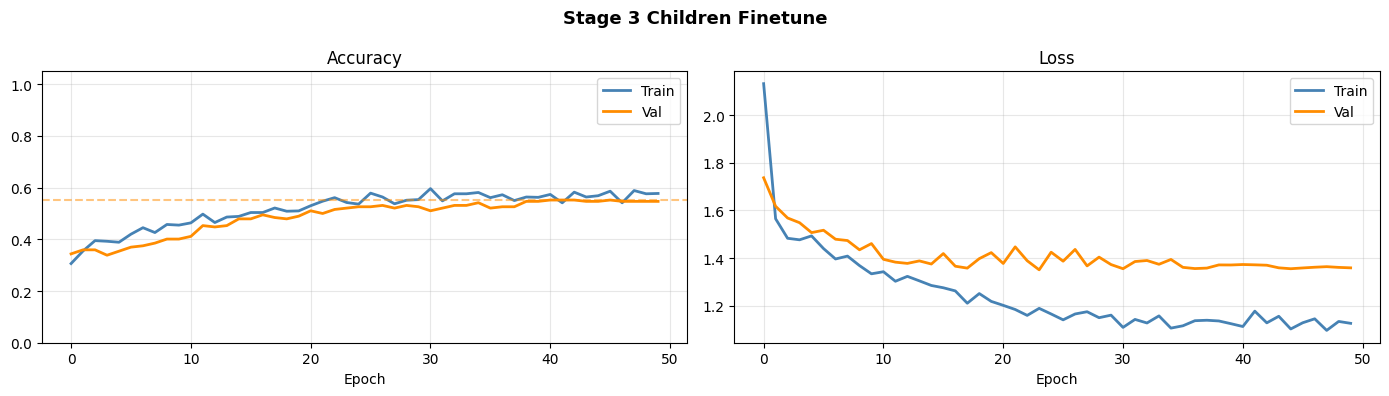

   Best val accuracy: 55.21%


In [26]:
# ── CELL 15 — STAGE 3: Children Finetune ─────────────────────

print(f'🚀 STAGE 3 — Children Finetune | LR = {LR_S3}\n')

history_s3 = model_s3.fit(
    children_train_gen,
    validation_data=children_val_gen,
    epochs=EPOCHS_S3,
    steps_per_epoch=math.floor(children_train_gen.samples / BATCH_CHILDREN),
    validation_steps=math.floor(children_val_gen.samples  / BATCH_CHILDREN),
    class_weight=cw_dict,
    callbacks=make_callbacks('stage3_children', patience_es=10, patience_lr=5),
    verbose=1
)

plot_history(history_s3, 'Stage 3 Children Finetune')
best_s3 = max(history_s3.history['val_accuracy'])

12/12 ━━━━━━━━━━━━━━━━━━━━ 153s 13s/step

🎯 Final Test Accuracy : 41.27%
   Final Test Loss     : 1.3869

              precision    recall  f1-score   support

     Natural     0.3478    0.4000    0.3721        40
       anger     0.4082    0.5000    0.4494        40
        fear     0.2632    0.1389    0.1818        36
         joy     0.7576    0.7143    0.7353        35
     sadness     0.2857    0.3158    0.3000        38

    accuracy                         0.4127       189
   macro avg     0.4125    0.4138    0.4077       189
weighted avg     0.4079    0.4127    0.4050       189



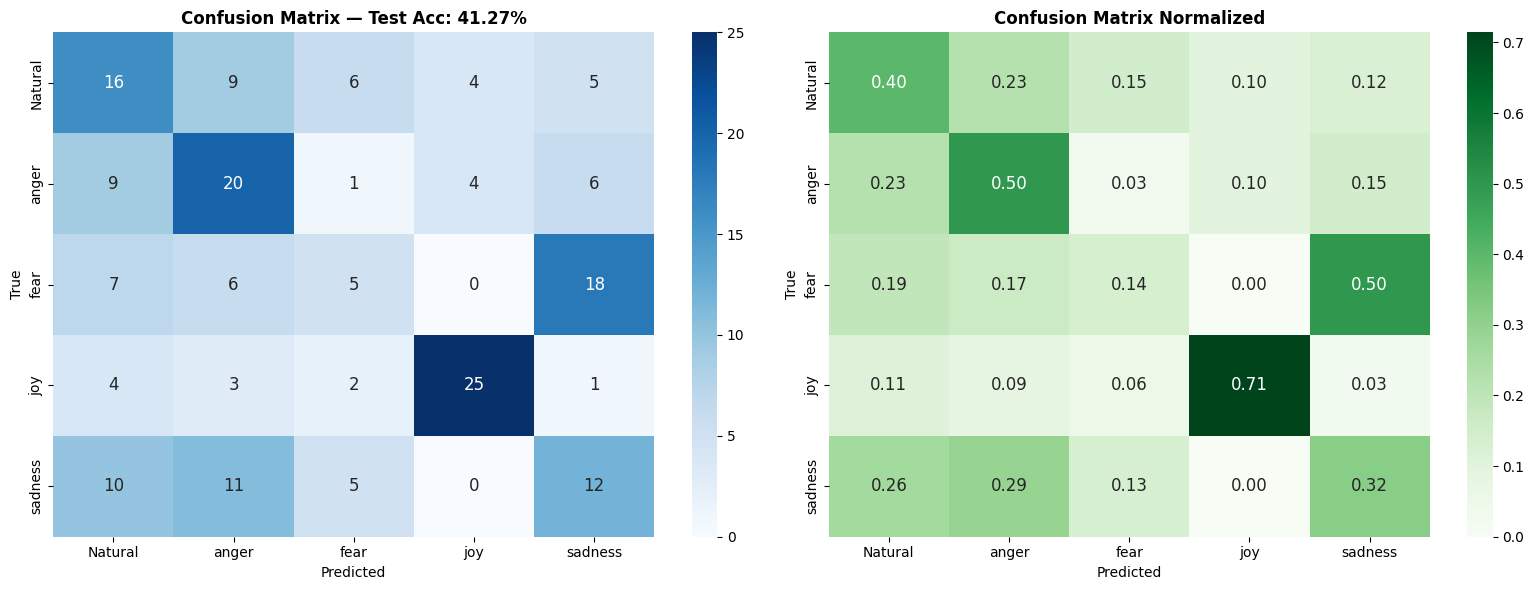

In [27]:
# ── CELL 16 — Full Evaluation ─────────────────────────────────

best_model = load_model(f'{SAVE_PATH}/stage3_children.keras')

y_probs = best_model.predict(children_test_gen, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)
y_true  = children_test_gen.classes[:len(y_pred)]
names   = list(children_test_gen.class_indices.keys())

test_loss, test_acc = best_model.evaluate(children_test_gen, verbose=0)

print(f'\n🎯 Final Test Accuracy : {test_acc*100:.2f}%')
print(f'   Final Test Loss     : {test_loss:.4f}\n')
print(classification_report(y_true, y_pred, target_names=names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names,
            ax=axes[0], annot_kws={'size': 12})
axes[0].set_title(f'Confusion Matrix — Test Acc: {test_acc*100:.2f}%',
                  fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=names, yticklabels=names,
            ax=axes[1], annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix Normalized', fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

📁 Upload a face image to test...


Saving Screenshot 2026-03-04 113227.png to Screenshot 2026-03-04 113227.png


/tmp/ipykernel_22354/1262375186.py:59: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')


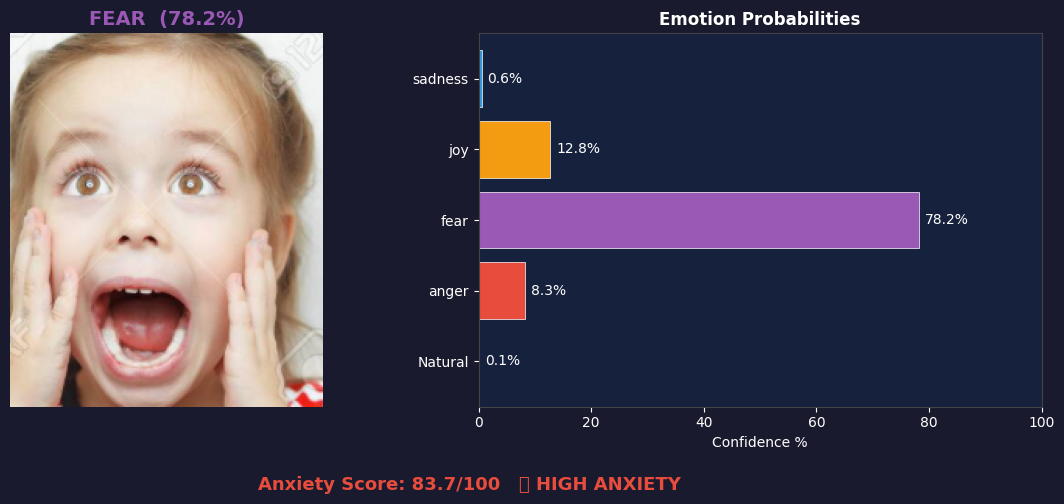


  PREDICTION RESULT
  Emotion       : FEAR
  Confidence    : 78.2%
  Anxiety Score : 83.7 / 100
  Anxiety Level : 🔴 HIGH ANXIETY
─────────────────────────────────────────────
  Natural   :   0.1%  
  anger     :   8.3%  ██
  fear      :  78.2%  ███████████████████████
  joy       :  12.8%  ███
  sadness   :   0.6%  


In [30]:
# ── CELL 17 — Test Single Image ───────────────────────────────

from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

COLORS = {
    'Natural': '#2ECC71', 'anger': '#E74C3C',
    'fear'   : '#9B59B6', 'joy'  : '#F39C12',
    'sadness': '#3498DB',
}

def predict_child(img_path, model):
    img   = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    top_idx     = np.argmax(probs)
    top_emotion = CHILDREN_CLASSES[top_idx]
    confidence  = probs[top_idx] * 100
    anxiety     = sum(probs[i] * ANXIETY_WEIGHTS.get(CHILDREN_CLASSES[i], 0)
                      for i in range(len(probs))) * 100

    if anxiety >= 60:
        level, lcolor = '🔴 HIGH ANXIETY',     '#E74C3C'
    elif anxiety >= 35:
        level, lcolor = '🟡 MODERATE ANXIETY', '#F39C12'
    else:
        level, lcolor = '🟢 CALM',             '#2ECC71'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.imshow(kimage.load_img(img_path))
    ax1.set_title(f'{top_emotion.upper()}  ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold',
                  color=COLORS.get(top_emotion, 'white'))
    ax1.axis('off')

    bars = ax2.barh(CHILDREN_CLASSES, probs * 100,
                    color=[COLORS[c] for c in CHILDREN_CLASSES],
                    edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel('Confidence %', color='white')
    ax2.set_title('Emotion Probabilities', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_facecolor('#16213e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444')
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', color='white', fontsize=10)

    fig.text(0.5, 0.01,
             f'Anxiety Score: {anxiety:.1f}/100   {level}',
             ha='center', fontsize=13, fontweight='bold', color=lcolor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*45)
    print('  PREDICTION RESULT')
    print('='*45)
    print(f'  Emotion       : {top_emotion.upper()}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Anxiety Score : {anxiety:.1f} / 100')
    print(f'  Anxiety Level : {level}')
    print('─'*45)
    for i, cls in enumerate(CHILDREN_CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'  {cls:10s}: {probs[i]*100:5.1f}%  {bar}')
    print('='*45)

print('📁 Upload a face image to test...')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]
predict_child(img_path, best_model)

📁 Upload a face image to test...


Saving Screenshot 2026-03-05 045135.png to Screenshot 2026-03-05 045135.png


/tmp/ipykernel_22354/1262375186.py:59: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')


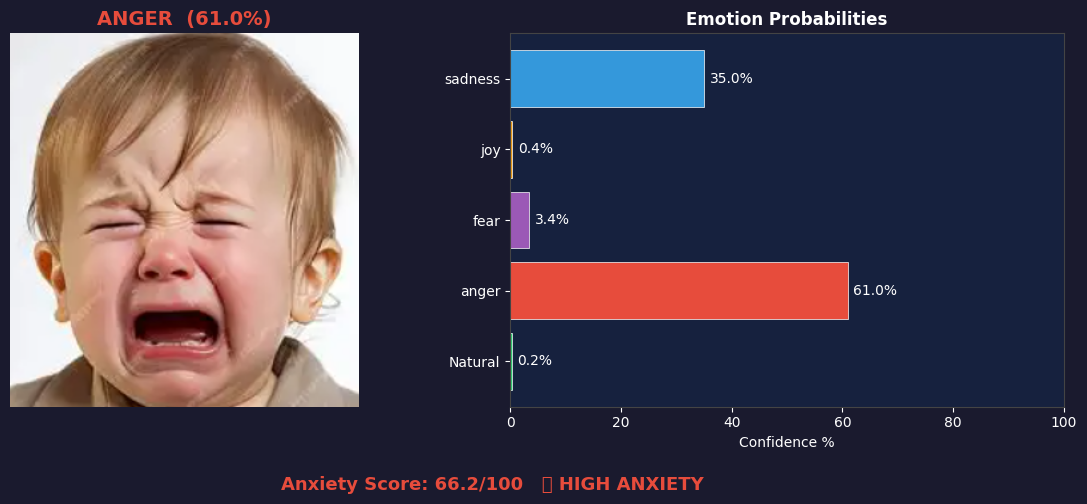


  PREDICTION RESULT
  Emotion       : ANGER
  Confidence    : 61.0%
  Anxiety Score : 66.2 / 100
  Anxiety Level : 🔴 HIGH ANXIETY
─────────────────────────────────────────────
  Natural   :   0.2%  
  anger     :  61.0%  ██████████████████
  fear      :   3.4%  █
  joy       :   0.4%  
  sadness   :  35.0%  ██████████


In [31]:
# ── CELL 17 — Test Single Image ───────────────────────────────

from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

COLORS = {
    'Natural': '#2ECC71', 'anger': '#E74C3C',
    'fear'   : '#9B59B6', 'joy'  : '#F39C12',
    'sadness': '#3498DB',
}

def predict_child(img_path, model):
    img   = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    top_idx     = np.argmax(probs)
    top_emotion = CHILDREN_CLASSES[top_idx]
    confidence  = probs[top_idx] * 100
    anxiety     = sum(probs[i] * ANXIETY_WEIGHTS.get(CHILDREN_CLASSES[i], 0)
                      for i in range(len(probs))) * 100

    if anxiety >= 60:
        level, lcolor = '🔴 HIGH ANXIETY',     '#E74C3C'
    elif anxiety >= 35:
        level, lcolor = '🟡 MODERATE ANXIETY', '#F39C12'
    else:
        level, lcolor = '🟢 CALM',             '#2ECC71'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.imshow(kimage.load_img(img_path))
    ax1.set_title(f'{top_emotion.upper()}  ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold',
                  color=COLORS.get(top_emotion, 'white'))
    ax1.axis('off')

    bars = ax2.barh(CHILDREN_CLASSES, probs * 100,
                    color=[COLORS[c] for c in CHILDREN_CLASSES],
                    edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel('Confidence %', color='white')
    ax2.set_title('Emotion Probabilities', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_facecolor('#16213e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444')
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', color='white', fontsize=10)

    fig.text(0.5, 0.01,
             f'Anxiety Score: {anxiety:.1f}/100   {level}',
             ha='center', fontsize=13, fontweight='bold', color=lcolor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*45)
    print('  PREDICTION RESULT')
    print('='*45)
    print(f'  Emotion       : {top_emotion.upper()}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Anxiety Score : {anxiety:.1f} / 100')
    print(f'  Anxiety Level : {level}')
    print('─'*45)
    for i, cls in enumerate(CHILDREN_CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'  {cls:10s}: {probs[i]*100:5.1f}%  {bar}')
    print('='*45)

print('📁 Upload a face image to test...')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]
predict_child(img_path, best_model)

📁 Upload a face image to test...


Saving Screenshot 2026-03-05 044148.png to Screenshot 2026-03-05 044148.png


/tmp/ipykernel_22354/1262375186.py:59: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


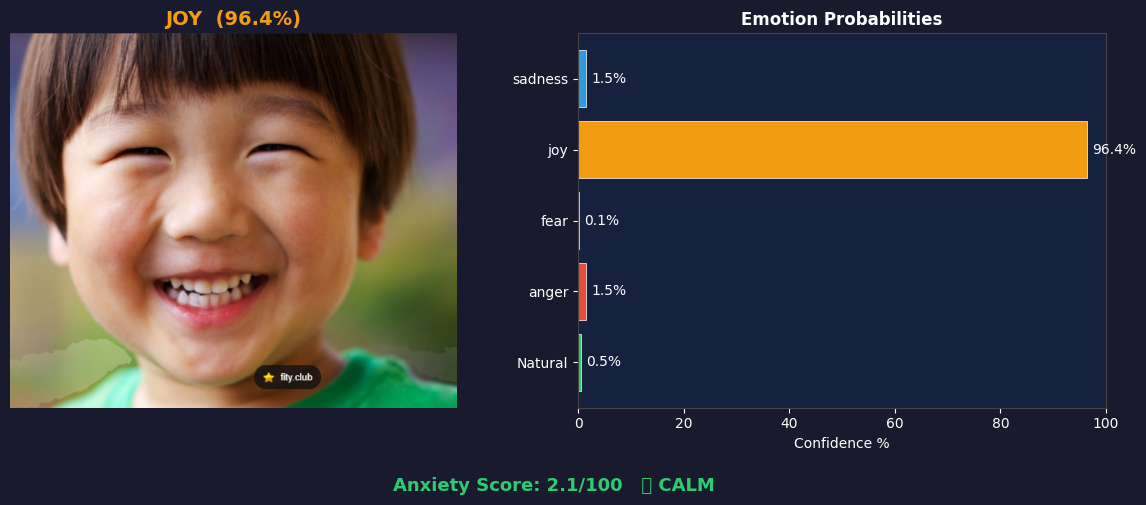


  PREDICTION RESULT
  Emotion       : JOY
  Confidence    : 96.4%
  Anxiety Score : 2.1 / 100
  Anxiety Level : 🟢 CALM
─────────────────────────────────────────────
  Natural   :   0.5%  
  anger     :   1.5%  
  fear      :   0.1%  
  joy       :  96.4%  ████████████████████████████
  sadness   :   1.5%  


In [32]:
# ── CELL 17 — Test Single Image ───────────────────────────────

from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

COLORS = {
    'Natural': '#2ECC71', 'anger': '#E74C3C',
    'fear'   : '#9B59B6', 'joy'  : '#F39C12',
    'sadness': '#3498DB',
}

def predict_child(img_path, model):
    img   = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    top_idx     = np.argmax(probs)
    top_emotion = CHILDREN_CLASSES[top_idx]
    confidence  = probs[top_idx] * 100
    anxiety     = sum(probs[i] * ANXIETY_WEIGHTS.get(CHILDREN_CLASSES[i], 0)
                      for i in range(len(probs))) * 100

    if anxiety >= 60:
        level, lcolor = '🔴 HIGH ANXIETY',     '#E74C3C'
    elif anxiety >= 35:
        level, lcolor = '🟡 MODERATE ANXIETY', '#F39C12'
    else:
        level, lcolor = '🟢 CALM',             '#2ECC71'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.imshow(kimage.load_img(img_path))
    ax1.set_title(f'{top_emotion.upper()}  ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold',
                  color=COLORS.get(top_emotion, 'white'))
    ax1.axis('off')

    bars = ax2.barh(CHILDREN_CLASSES, probs * 100,
                    color=[COLORS[c] for c in CHILDREN_CLASSES],
                    edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel('Confidence %', color='white')
    ax2.set_title('Emotion Probabilities', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_facecolor('#16213e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444')
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', color='white', fontsize=10)

    fig.text(0.5, 0.01,
             f'Anxiety Score: {anxiety:.1f}/100   {level}',
             ha='center', fontsize=13, fontweight='bold', color=lcolor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*45)
    print('  PREDICTION RESULT')
    print('='*45)
    print(f'  Emotion       : {top_emotion.upper()}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Anxiety Score : {anxiety:.1f} / 100')
    print(f'  Anxiety Level : {level}')
    print('─'*45)
    for i, cls in enumerate(CHILDREN_CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'  {cls:10s}: {probs[i]*100:5.1f}%  {bar}')
    print('='*45)

print('📁 Upload a face image to test...')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]
predict_child(img_path, best_model)

📁 Upload a face image to test...


Saving Screenshot 2026-03-05 044708.png to Screenshot 2026-03-05 044708.png


/tmp/ipykernel_22354/1262375186.py:59: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


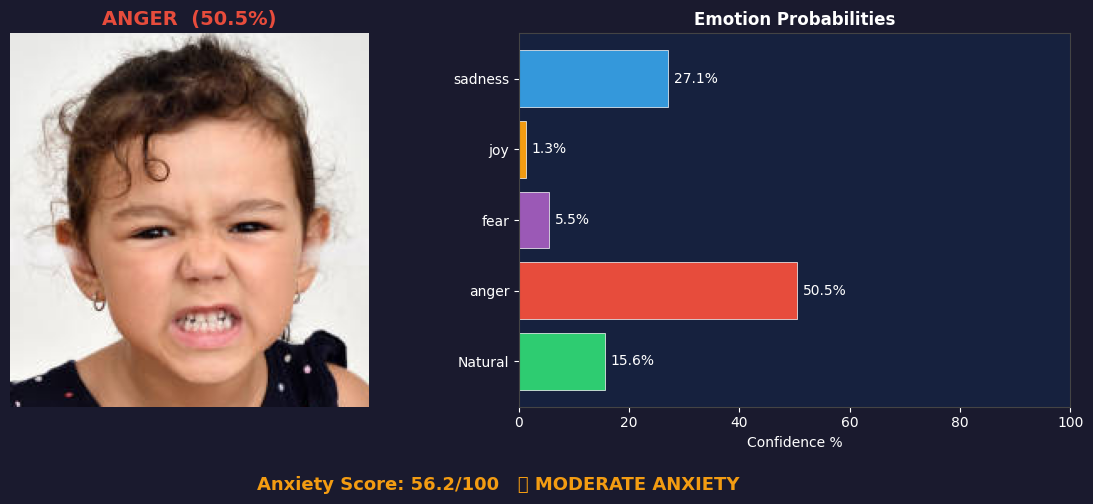


  PREDICTION RESULT
  Emotion       : ANGER
  Confidence    : 50.5%
  Anxiety Score : 56.2 / 100
  Anxiety Level : 🟡 MODERATE ANXIETY
─────────────────────────────────────────────
  Natural   :  15.6%  ████
  anger     :  50.5%  ███████████████
  fear      :   5.5%  █
  joy       :   1.3%  
  sadness   :  27.1%  ████████


In [33]:
# ── CELL 17 — Test Single Image ───────────────────────────────

from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

COLORS = {
    'Natural': '#2ECC71', 'anger': '#E74C3C',
    'fear'   : '#9B59B6', 'joy'  : '#F39C12',
    'sadness': '#3498DB',
}

def predict_child(img_path, model):
    img   = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    top_idx     = np.argmax(probs)
    top_emotion = CHILDREN_CLASSES[top_idx]
    confidence  = probs[top_idx] * 100
    anxiety     = sum(probs[i] * ANXIETY_WEIGHTS.get(CHILDREN_CLASSES[i], 0)
                      for i in range(len(probs))) * 100

    if anxiety >= 60:
        level, lcolor = '🔴 HIGH ANXIETY',     '#E74C3C'
    elif anxiety >= 35:
        level, lcolor = '🟡 MODERATE ANXIETY', '#F39C12'
    else:
        level, lcolor = '🟢 CALM',             '#2ECC71'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.imshow(kimage.load_img(img_path))
    ax1.set_title(f'{top_emotion.upper()}  ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold',
                  color=COLORS.get(top_emotion, 'white'))
    ax1.axis('off')

    bars = ax2.barh(CHILDREN_CLASSES, probs * 100,
                    color=[COLORS[c] for c in CHILDREN_CLASSES],
                    edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel('Confidence %', color='white')
    ax2.set_title('Emotion Probabilities', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_facecolor('#16213e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444')
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', color='white', fontsize=10)

    fig.text(0.5, 0.01,
             f'Anxiety Score: {anxiety:.1f}/100   {level}',
             ha='center', fontsize=13, fontweight='bold', color=lcolor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*45)
    print('  PREDICTION RESULT')
    print('='*45)
    print(f'  Emotion       : {top_emotion.upper()}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Anxiety Score : {anxiety:.1f} / 100')
    print(f'  Anxiety Level : {level}')
    print('─'*45)
    for i, cls in enumerate(CHILDREN_CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'  {cls:10s}: {probs[i]*100:5.1f}%  {bar}')
    print('='*45)

print('📁 Upload a face image to test...')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]
predict_child(img_path, best_model)

📁 Upload a face image to test...


Saving Screenshot 2026-03-04 150554.png to Screenshot 2026-03-04 150554.png


/tmp/ipykernel_22354/1262375186.py:59: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')


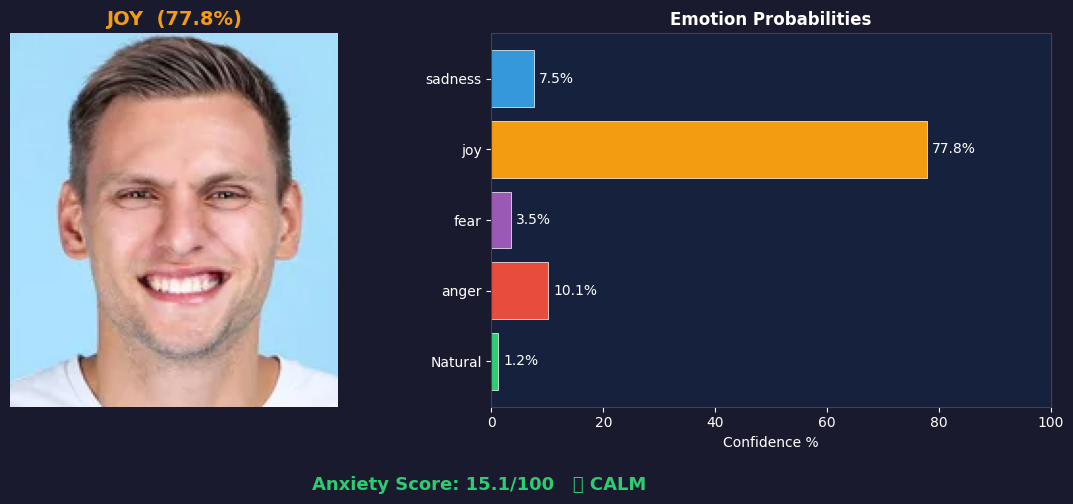


  PREDICTION RESULT
  Emotion       : JOY
  Confidence    : 77.8%
  Anxiety Score : 15.1 / 100
  Anxiety Level : 🟢 CALM
─────────────────────────────────────────────
  Natural   :   1.2%  
  anger     :  10.1%  ███
  fear      :   3.5%  █
  joy       :  77.8%  ███████████████████████
  sadness   :   7.5%  ██


In [34]:
# ── CELL 17 — Test Single Image ───────────────────────────────

from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

COLORS = {
    'Natural': '#2ECC71', 'anger': '#E74C3C',
    'fear'   : '#9B59B6', 'joy'  : '#F39C12',
    'sadness': '#3498DB',
}

def predict_child(img_path, model):
    img   = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    top_idx     = np.argmax(probs)
    top_emotion = CHILDREN_CLASSES[top_idx]
    confidence  = probs[top_idx] * 100
    anxiety     = sum(probs[i] * ANXIETY_WEIGHTS.get(CHILDREN_CLASSES[i], 0)
                      for i in range(len(probs))) * 100

    if anxiety >= 60:
        level, lcolor = '🔴 HIGH ANXIETY',     '#E74C3C'
    elif anxiety >= 35:
        level, lcolor = '🟡 MODERATE ANXIETY', '#F39C12'
    else:
        level, lcolor = '🟢 CALM',             '#2ECC71'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.imshow(kimage.load_img(img_path))
    ax1.set_title(f'{top_emotion.upper()}  ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold',
                  color=COLORS.get(top_emotion, 'white'))
    ax1.axis('off')

    bars = ax2.barh(CHILDREN_CLASSES, probs * 100,
                    color=[COLORS[c] for c in CHILDREN_CLASSES],
                    edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel('Confidence %', color='white')
    ax2.set_title('Emotion Probabilities', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_facecolor('#16213e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444')
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', color='white', fontsize=10)

    fig.text(0.5, 0.01,
             f'Anxiety Score: {anxiety:.1f}/100   {level}',
             ha='center', fontsize=13, fontweight='bold', color=lcolor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*45)
    print('  PREDICTION RESULT')
    print('='*45)
    print(f'  Emotion       : {top_emotion.upper()}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Anxiety Score : {anxiety:.1f} / 100')
    print(f'  Anxiety Level : {level}')
    print('─'*45)
    for i, cls in enumerate(CHILDREN_CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'  {cls:10s}: {probs[i]*100:5.1f}%  {bar}')
    print('='*45)

print('📁 Upload a face image to test...')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]
predict_child(img_path, best_model)

📁 Upload a face image to test...


Saving Screenshot 2026-03-05 223705.png to Screenshot 2026-03-05 223705.png


/tmp/ipykernel_22354/1262375186.py:59: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')


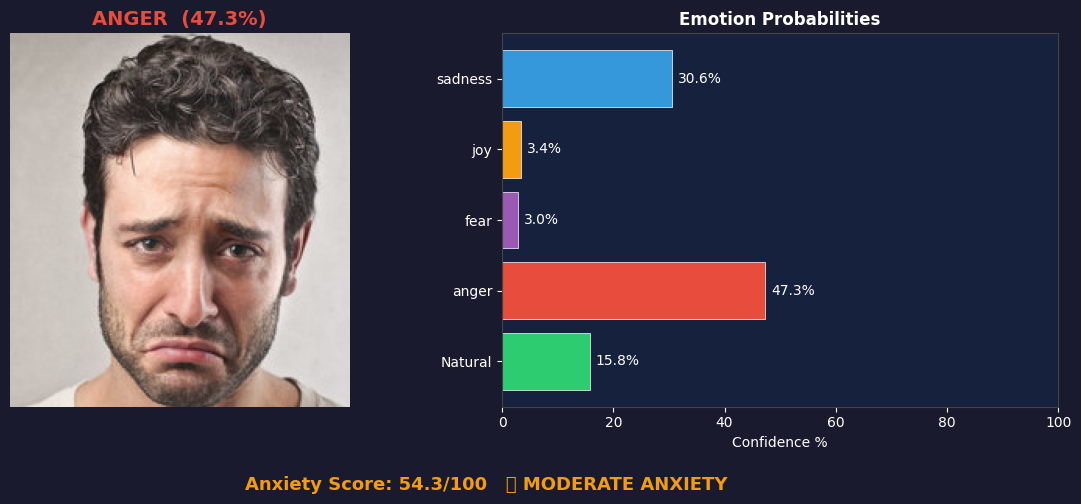


  PREDICTION RESULT
  Emotion       : ANGER
  Confidence    : 47.3%
  Anxiety Score : 54.3 / 100
  Anxiety Level : 🟡 MODERATE ANXIETY
─────────────────────────────────────────────
  Natural   :  15.8%  ████
  anger     :  47.3%  ██████████████
  fear      :   3.0%  
  joy       :   3.4%  █
  sadness   :  30.6%  █████████


In [35]:
# ── CELL 17 — Test Single Image ───────────────────────────────

from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

COLORS = {
    'Natural': '#2ECC71', 'anger': '#E74C3C',
    'fear'   : '#9B59B6', 'joy'  : '#F39C12',
    'sadness': '#3498DB',
}

def predict_child(img_path, model):
    img   = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    top_idx     = np.argmax(probs)
    top_emotion = CHILDREN_CLASSES[top_idx]
    confidence  = probs[top_idx] * 100
    anxiety     = sum(probs[i] * ANXIETY_WEIGHTS.get(CHILDREN_CLASSES[i], 0)
                      for i in range(len(probs))) * 100

    if anxiety >= 60:
        level, lcolor = '🔴 HIGH ANXIETY',     '#E74C3C'
    elif anxiety >= 35:
        level, lcolor = '🟡 MODERATE ANXIETY', '#F39C12'
    else:
        level, lcolor = '🟢 CALM',             '#2ECC71'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.imshow(kimage.load_img(img_path))
    ax1.set_title(f'{top_emotion.upper()}  ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold',
                  color=COLORS.get(top_emotion, 'white'))
    ax1.axis('off')

    bars = ax2.barh(CHILDREN_CLASSES, probs * 100,
                    color=[COLORS[c] for c in CHILDREN_CLASSES],
                    edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel('Confidence %', color='white')
    ax2.set_title('Emotion Probabilities', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_facecolor('#16213e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444')
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', color='white', fontsize=10)

    fig.text(0.5, 0.01,
             f'Anxiety Score: {anxiety:.1f}/100   {level}',
             ha='center', fontsize=13, fontweight='bold', color=lcolor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*45)
    print('  PREDICTION RESULT')
    print('='*45)
    print(f'  Emotion       : {top_emotion.upper()}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Anxiety Score : {anxiety:.1f} / 100')
    print(f'  Anxiety Level : {level}')
    print('─'*45)
    for i, cls in enumerate(CHILDREN_CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'  {cls:10s}: {probs[i]*100:5.1f}%  {bar}')
    print('='*45)

print('📁 Upload a face image to test...')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]
predict_child(img_path, best_model)

In [ ]:
# ── CELL 17 — Test Single Image ───────────────────────────────

from google.colab import files
from tensorflow.keras.preprocessing import image as kimage

COLORS = {
    'Natural': '#2ECC71', 'anger': '#E74C3C',
    'fear'   : '#9B59B6', 'joy'  : '#F39C12',
    'sadness': '#3498DB',
}

def predict_child(img_path, model):
    img   = kimage.load_img(img_path, target_size=IMG_SIZE)
    arr   = kimage.img_to_array(img) / 255.0
    arr   = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]

    top_idx     = np.argmax(probs)
    top_emotion = CHILDREN_CLASSES[top_idx]
    confidence  = probs[top_idx] * 100
    anxiety     = sum(probs[i] * ANXIETY_WEIGHTS.get(CHILDREN_CLASSES[i], 0)
                      for i in range(len(probs))) * 100

    if anxiety >= 60:
        level, lcolor = '🔴 HIGH ANXIETY',     '#E74C3C'
    elif anxiety >= 35:
        level, lcolor = '🟡 MODERATE ANXIETY', '#F39C12'
    else:
        level, lcolor = '🟢 CALM',             '#2ECC71'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.imshow(kimage.load_img(img_path))
    ax1.set_title(f'{top_emotion.upper()}  ({confidence:.1f}%)',
                  fontsize=14, fontweight='bold',
                  color=COLORS.get(top_emotion, 'white'))
    ax1.axis('off')

    bars = ax2.barh(CHILDREN_CLASSES, probs * 100,
                    color=[COLORS[c] for c in CHILDREN_CLASSES],
                    edgecolor='white', linewidth=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_xlabel('Confidence %', color='white')
    ax2.set_title('Emotion Probabilities', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    ax2.set_facecolor('#16213e')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#444')
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', color='white', fontsize=10)

    fig.text(0.5, 0.01,
             f'Anxiety Score: {anxiety:.1f}/100   {level}',
             ha='center', fontsize=13, fontweight='bold', color=lcolor)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'{SAVE_PATH}/test_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*45)
    print('  PREDICTION RESULT')
    print('='*45)
    print(f'  Emotion       : {top_emotion.upper()}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Anxiety Score : {anxiety:.1f} / 100')
    print(f'  Anxiety Level : {level}')
    print('─'*45)
    for i, cls in enumerate(CHILDREN_CLASSES):
        bar = '█' * int(probs[i] * 30)
        print(f'  {cls:10s}: {probs[i]*100:5.1f}%  {bar}')
    print('='*45)

print('📁 Upload a face image to test...')
uploaded  = files.upload()
img_path  = list(uploaded.keys())[0]
predict_child(img_path, best_model)

📁 Upload a face image to test...


In [29]:
# ── CELL 18 — Final Summary & Save ───────────────────────────

best_model.save(f'{SAVE_PATH}/final_child_anxiety_model_v2.keras')

print('=' * 60)
print('  FINAL TRAINING SUMMARY — 3 Stage Pipeline')
print('=' * 60)
print(f'  Stage 1  (AffectNet frozen)  : {max(history_s1.history["val_accuracy"])*100:.2f}%')
print(f'  Stage 1B (AffectNet unfrozen): {max(history_s1b.history["val_accuracy"])*100:.2f}%')
print(f'  Stage 2  (RAF-DB finetune)   : {max(history_s2.history["val_accuracy"])*100:.2f}%')
print(f'  Stage 3  (Children finetune) : {max(history_s3.history["val_accuracy"])*100:.2f}%')
print(f'  ──────────────────────────────────────────')
print(f'  FINAL TEST ACCURACY          : {test_acc*100:.2f}%')
print(f'  FINAL TEST LOSS              : {test_loss:.4f}')
print()
print('  Pipeline:')
print('  AffectNet(5) → RAF-DB(5) → Children(5)')
print()
print('  Saved → final_child_anxiety_model_v2.keras')
print('=' * 60)

  FINAL TRAINING SUMMARY — 3 Stage Pipeline
  Stage 1  (AffectNet frozen)  : 63.04%
  Stage 1B (AffectNet unfrozen): 73.32%
  Stage 2  (RAF-DB finetune)   : 74.15%
  Stage 3  (Children finetune) : 55.21%
  ──────────────────────────────────────────
  FINAL TEST ACCURACY          : 41.27%
  FINAL TEST LOSS              : 1.3869

  Pipeline:
  AffectNet(5) → RAF-DB(5) → Children(5)

  Saved → final_child_anxiety_model_v2.keras
